In [22]:
# !pip install hurst
# !pip install arch
# !pip install bspline

In [23]:
import sys
!{sys.executable} --version
# !pip install bspline

import os
import math
from math import log
from datetime import datetime, timedelta

# import pickle
import numpy as np
from hurst import compute_Hc
from arch import arch_model
from IPython.display import display
import matplotlib.pyplot as plt

import pandas as pd
import yfinance as yf
from yahoofinancials import YahooFinancials
from IPython.display import display

%matplotlib inline

# import function libraries for calculating value at risk and computing backtesting statistics

from quantile_functions import *
from VaR_backtest_tests import *

# prices = pickle.load(open('stock_prices.pkl','rb'))

# # convert from prices to returns
# returns = dict()
# for k in list(prices.keys()):
#     returns[k] = get_stock_log_returns(prices[k])

Python 3.11.5


# download price history

In [24]:
companies, tickers = ['Meta'],['META']

tickers_df = yf.download(tickers, 
                      start='2017-01-01', 
                      end='2026-01-30', 
                      progress=False, auto_adjust=True)
display(tickers_df.head())
display(tickers_df.tail())

Price,Close,High,Low,Open,Volume
Ticker,META,META,META,META,META
Date,,,,,
2017-01-03,116.049355,117.022552,114.708721,115.225110,20663900
2017-01-04,117.866661,118.829933,116.476371,116.734570,19630900
2017-01-05,119.832932,120.110988,117.499235,118.035490,19492200
2017-01-06,122.553925,123.020658,119.197366,120.140781,28545300
2017-01-09,124.033592,124.559914,122.186494,122.692958,22880400


Price,Close,High,Low,Open,Volume
Ticker,META,META,META,META,META
Date,,,,,
2026-01-23,658.760010,666.489990,644.450012,644.770020,22797700
2026-01-26,672.359985,675.280029,661.289978,665.130005,16327400
2026-01-27,672.969971,676.820007,664.659973,674.590027,13297400
2026-01-28,668.729980,677.679993,666.099976,674.500000,25709600
2026-01-29,738.309998,744.000000,712.549988,737.429993,59852900


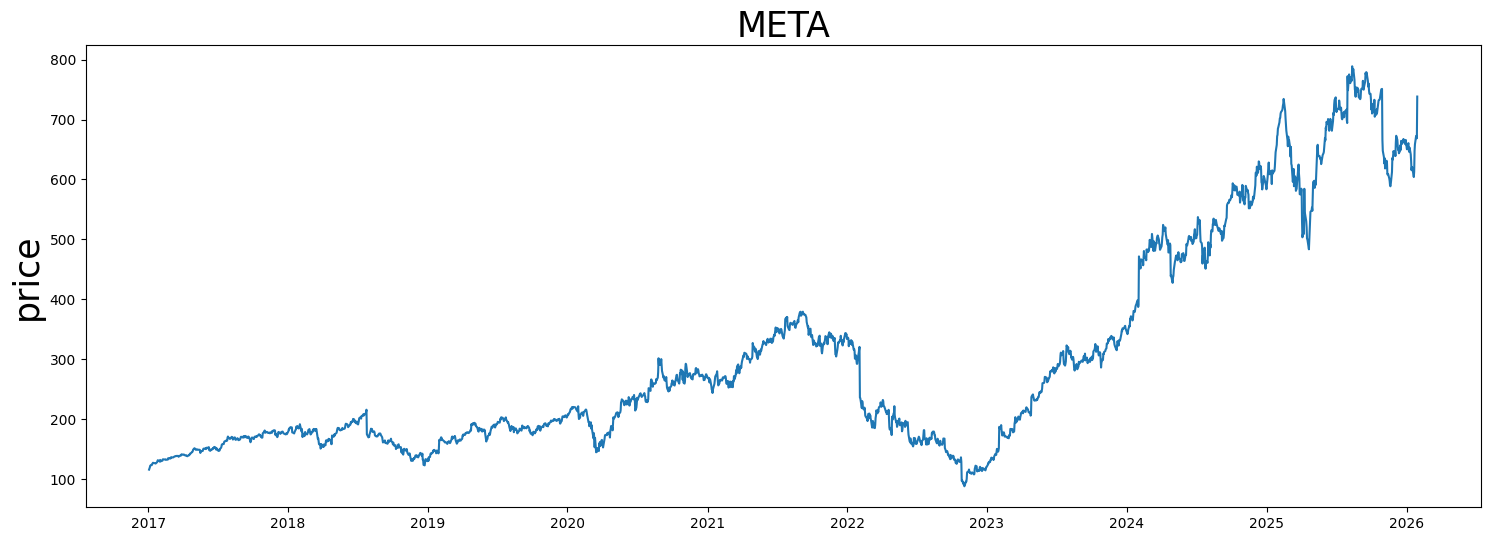

In [25]:
ticker = tickers[0]
prices = {ticker: tickers_df['Close']}

plt.figure(figsize=(18,6))
plt.plot(prices[ticker])
plt.title(ticker, fontsize=25)
plt.ylabel('price', fontsize=25)             
plt.show()

# plot daily returns

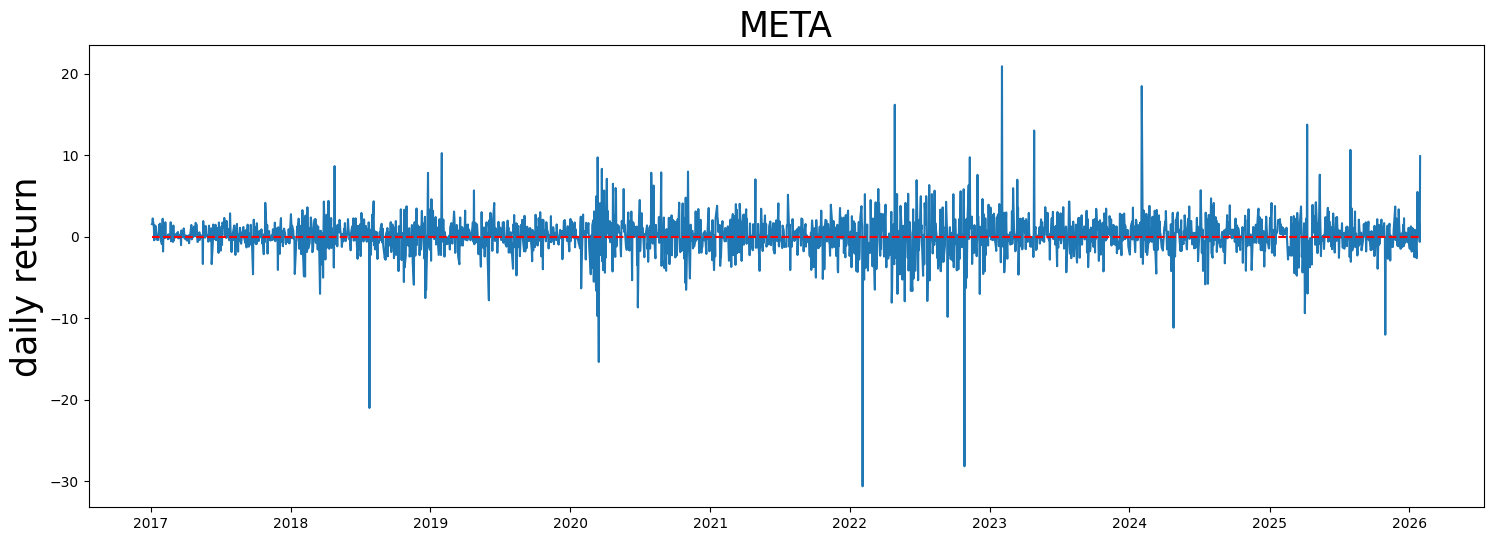

In [26]:
returns = {ticker: tickers_df[('Close','META')].apply(log).diff()[1:]}
train = returns[ticker] * 100
train2 = train * train

plt.figure(figsize=(18,6))
plt.plot(train)
plt.title(ticker, fontsize=25)
plt.plot([train.index[0], train.index[-1]], [0,0], '--',color='red')
plt.ylabel('daily return', fontsize=25) 
plt.show()

# Historical distribution of returns

In [27]:
p = 0.05

nonparametric 95.0% Value at Risk = -3.7046


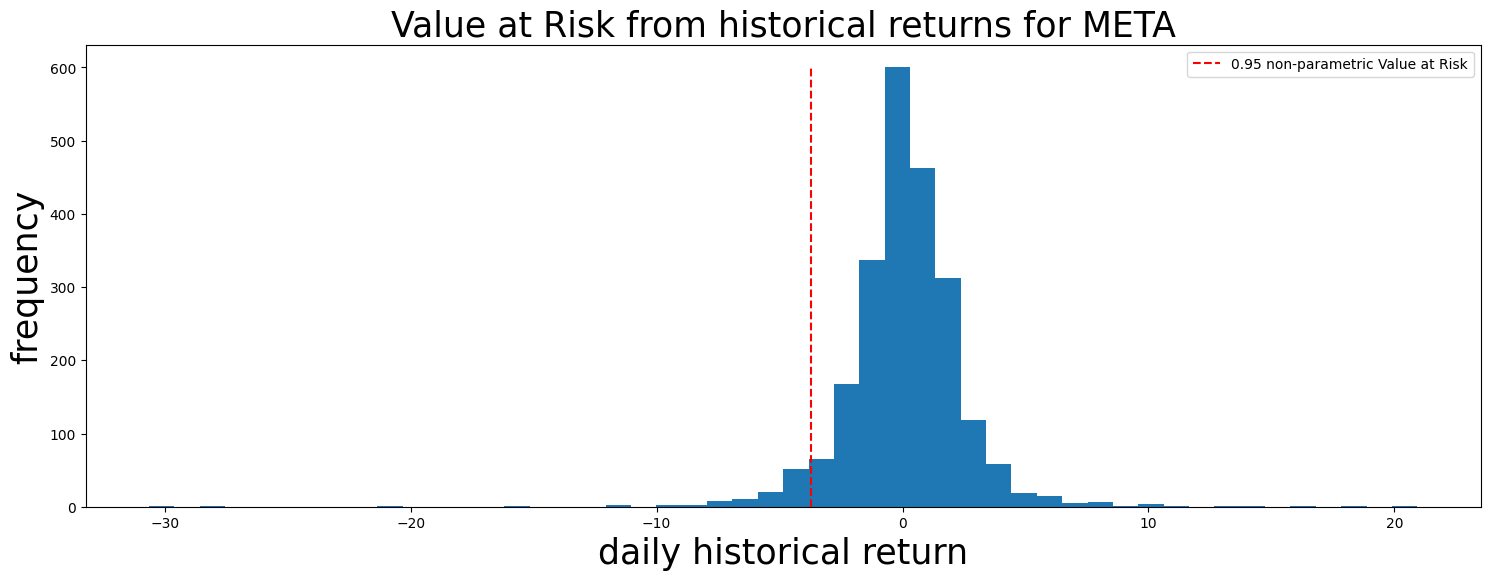

In [28]:
plt.figure(figsize=(18,6))
hist = plt.hist(train,50)
plt.title(f'Value at Risk from historical returns for {ticker}', fontsize=25)
plt.xlabel('daily historical return', fontsize=25)
plt.ylabel('frequency', fontsize=25)

VaRcutoff = np.quantile(train, p)
print(f"nonparametric {100 - 100 * p}% Value at Risk = {VaRcutoff:0.4f}")
plt.plot([VaRcutoff,VaRcutoff],[0, max(hist[0])], '--',color='red', label=f"{1-p} non-parametric Value at Risk")
plt.legend()
plt.show()

# VaR assuming a Gaussian distribution

daily return mean = 0.081156 and standard deviation = 2.516739

cutoff = -1.6449 * 2.5167 at probability 0.05

parametric 95.0% Value at Risk = -4.1397


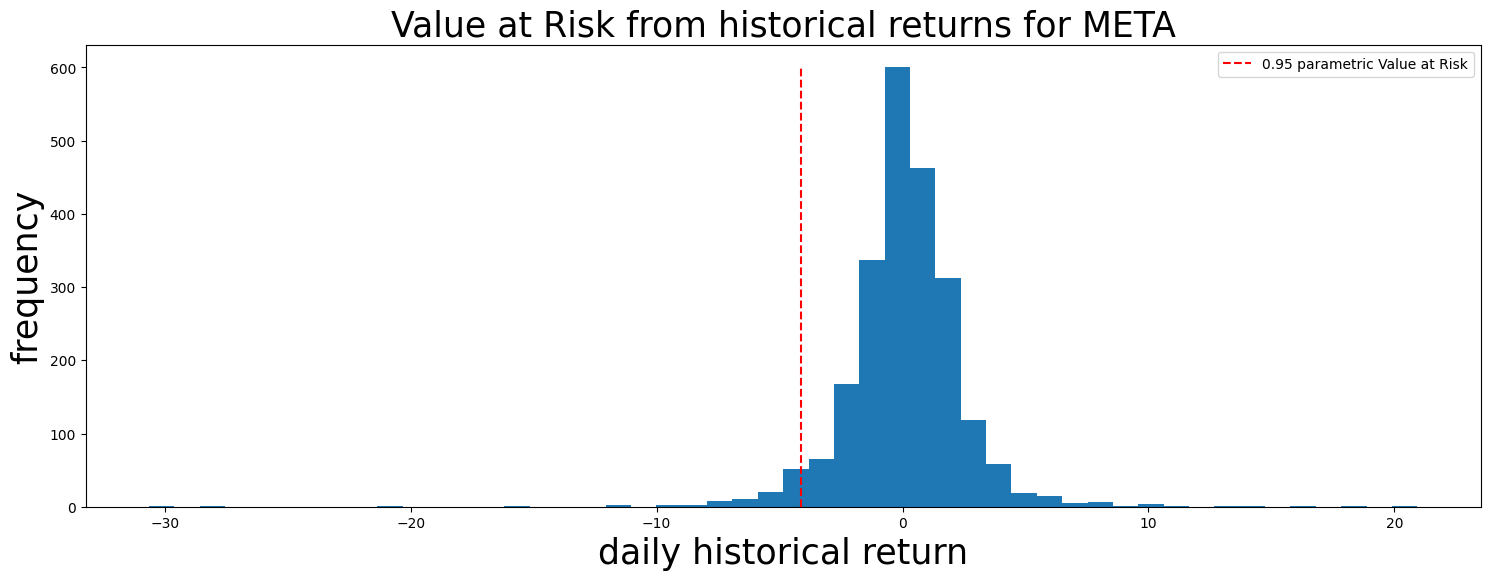

In [29]:
from scipy.stats import norm

mu, sigma = np.mean(train), np.std(train)
print(f"daily return mean = {mu:0.6f} and standard deviation = {sigma:0.6f}")

plt.figure(figsize=(18,6))
hist = plt.hist(train,50)
plt.title(f'Value at Risk from historical returns for {ticker}', fontsize=25)
plt.xlabel('daily historical return', fontsize=25)
plt.ylabel('frequency', fontsize=25)

VaRcutoff = norm.ppf(p) * sigma
print(f"\ncutoff = {norm.ppf(p):0.4f} * {sigma:0.4f} at probability {p}")
print(f"\nparametric {100 - 100 * p}% Value at Risk = {VaRcutoff:0.4f}")
plt.plot([VaRcutoff,VaRcutoff],[0, max(hist[0])], '--',color='red', label=f"{1-p} parametric Value at Risk")
plt.legend()
plt.show()

# MA: Fit interval moving average value at risk
## note abrupt drop and rise in VaR in late 2018

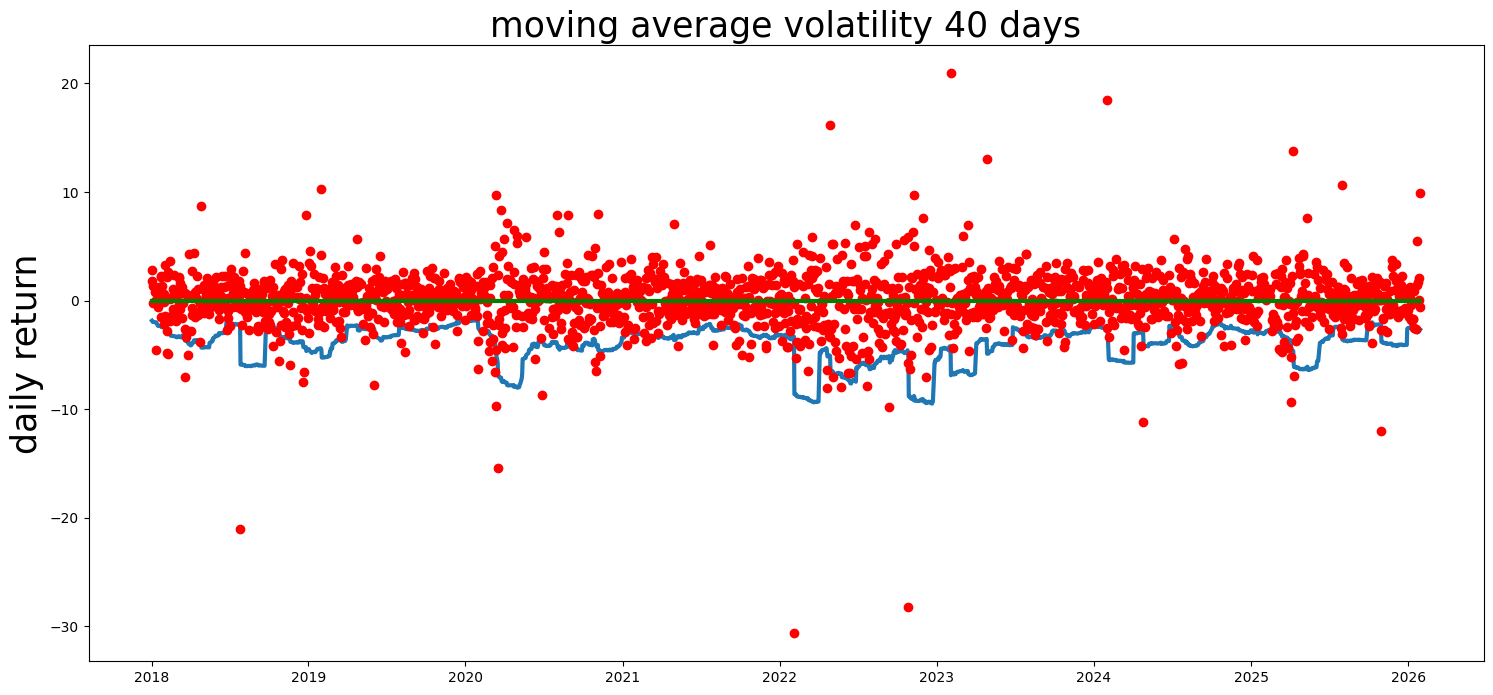

In [30]:
history_n = 40  # length of window for calculating historical volatility
MAVaR40 = [-1.645 * np.sqrt(np.mean(train2[i:i+history_n])) for i,_ in enumerate(train2[:-history_n])]

MAVaR40_df = pd.DataFrame(MAVaR40[:], index=pd.DataFrame(train).index[40:], columns=['VaR'])
plt.figure(figsize=(18,8))
start_date = '2018-01-01'
plt.plot(MAVaR40_df[start_date:]['VaR'],linewidth=3)
plt.plot(pd.DataFrame(train[start_date:]), 'ro')
plt.plot(pd.DataFrame([0,0],index=MAVaR40_df[start_date:].index[[0,-1]]), 'g-',linewidth=3)
plt.title(f"moving average volatility {history_n} days", fontsize=25)
plt.ylabel('daily return', fontsize=25)
plt.show()

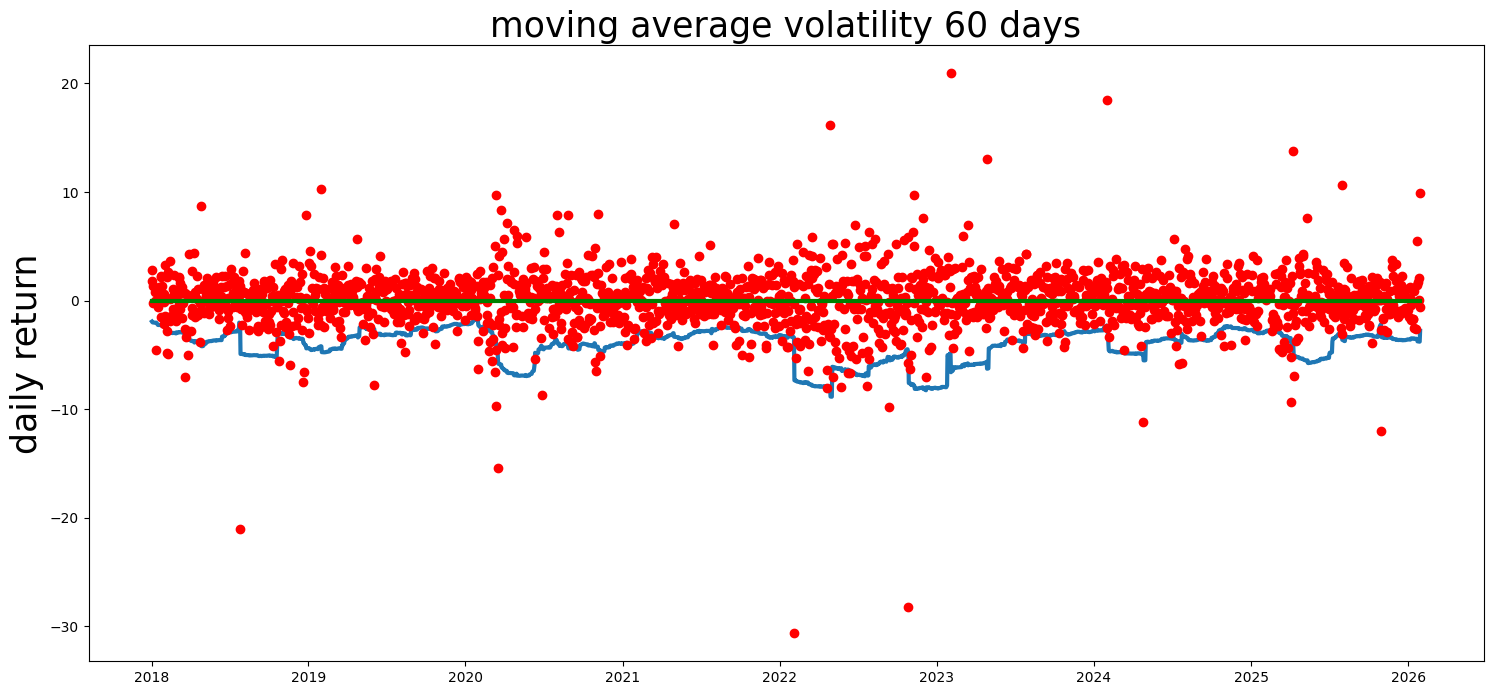

In [31]:
history_n = 60  # length of window for calculating historical volatility
MAVaR60 = [-1.645 * np.sqrt(np.mean(train2[i:i+history_n])) for i,_ in enumerate(train2[:-history_n])]

MAVaR60_df = pd.DataFrame(MAVaR60[:], index=pd.DataFrame(train).index[history_n:], columns=['VaR'])

plt.figure(figsize=(18,8))
start_date = '2018-01-01'
plt.plot(MAVaR60_df[start_date:]['VaR'],linewidth=3)
plt.plot(pd.DataFrame(train[start_date:]), 'ro')
plt.plot(pd.DataFrame([0,0],index=MAVaR60_df[start_date:].index[[0,-1]]), 'g-',linewidth=3)
plt.title(f"moving average volatility {history_n} days", fontsize=25)
plt.ylabel('daily return', fontsize=25)
plt.show()

# Comparison of 40 vs 60 day Moving Average

In [32]:
MAV = pd.concat([MAVaR40_df, MAVaR40_df.diff(), MAVaR60_df, MAVaR60_df.diff()], axis=1)
MAV.columns = ['40 day MA','diff 40 day MA','60 day MA','diff 60 day MA']
display(MAV.tail())

,40 day MA,diff 40 day MA,60 day MA,diff 60 day MA
Date,,,,
2026-01-23,-2.929071,-0.363568,-3.756333,-0.184137
2026-01-26,-2.849492,0.079579,-3.756953,-0.000619
2026-01-27,-2.733323,0.116169,-3.781893,-0.024940
2026-01-28,-2.731333,0.001990,-3.781936,-0.000043
2026-01-29,-2.673642,0.057690,-2.791745,0.990191


In [33]:
top_5_diffs = MAV['diff 40 day MA'].nsmallest(5)
print("diff 40 day MA days with the largest increase in VaR")
print(top_5_diffs)

top_5_diffs = MAV['diff 60 day MA'].nsmallest(5)
print("\ndiff 60 day MA days with the largest increase in VaR")
print(top_5_diffs)


diff 40 day MA days with the largest increase in VaR
Date
2022-02-04   -5.300145
2022-10-28   -3.814100
2018-07-27   -3.666662
2024-02-05   -2.922952
2023-02-03   -2.666123
Name: diff 40 day MA, dtype: float64

diff 60 day MA days with the largest increase in VaR
Date
2022-02-04   -3.936239
2018-07-27   -2.843662
2022-10-28   -2.787261
2024-02-05   -2.223717
2023-02-03   -1.702338
Name: diff 60 day MA, dtype: float64


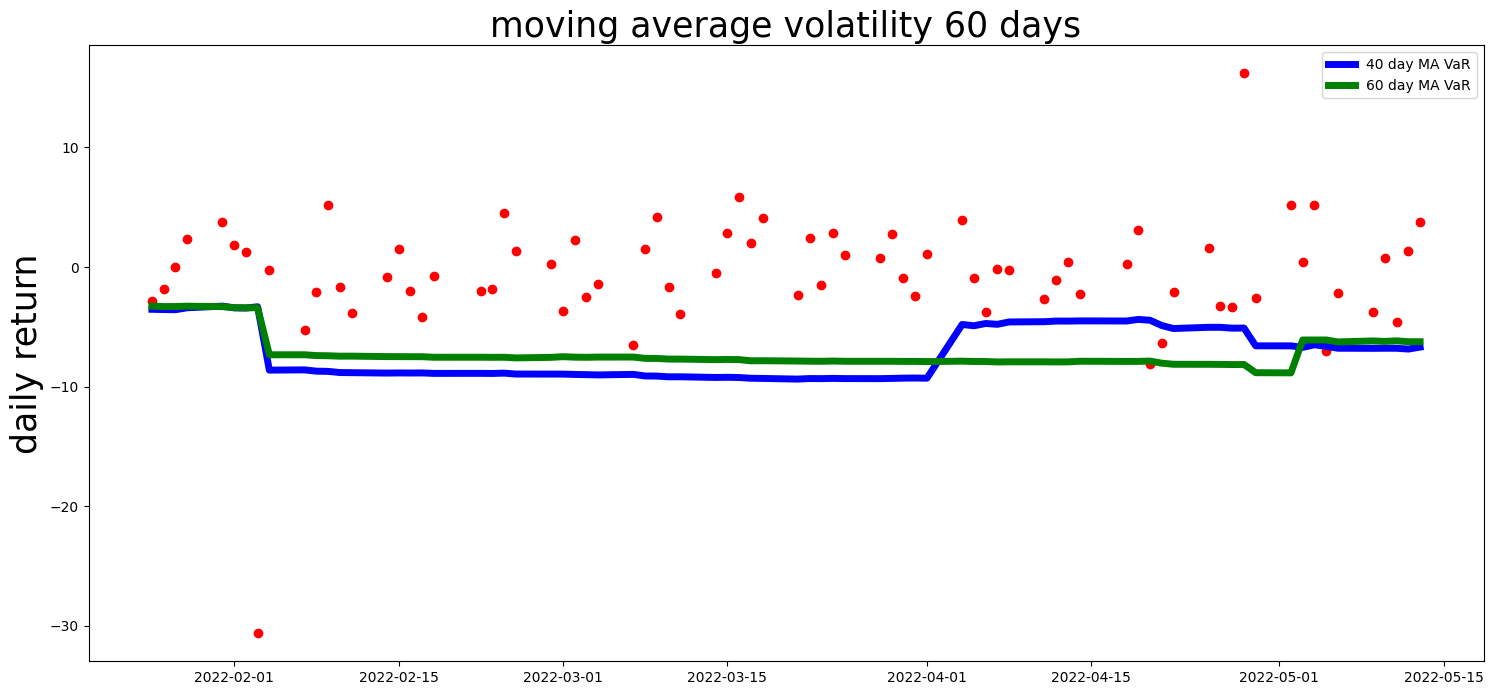

In [34]:
plt.figure(figsize=(18,8))
start_date = '2022-02-04'
_start_date = datetime.datetime.strptime(start_date, '%Y-%m-%d')
start_date = str(_start_date + timedelta(days=-10))[:10]
end_date = str(_start_date + timedelta(days=100))[:10]

plt.plot(pd.DataFrame(train[start_date:end_date]), 'ro')
plt.plot(MAV['40 day MA'][start_date:end_date], linewidth=5, color='blue', label='40 day MA VaR')
plt.plot(MAV['60 day MA'][start_date:end_date], linewidth=5, color='green', label='60 day MA VaR')

plt.title(f"moving average volatility {history_n} days", fontsize=25)
plt.ylabel('daily return', fontsize=25)
plt.legend()
plt.show()

# EWMA: exponential weighted moving average volatiity

$$\sigma^2_n = (1 - \lambda) u^2_{n-1} + \lambda \sigma^2_{n-1}$$ 

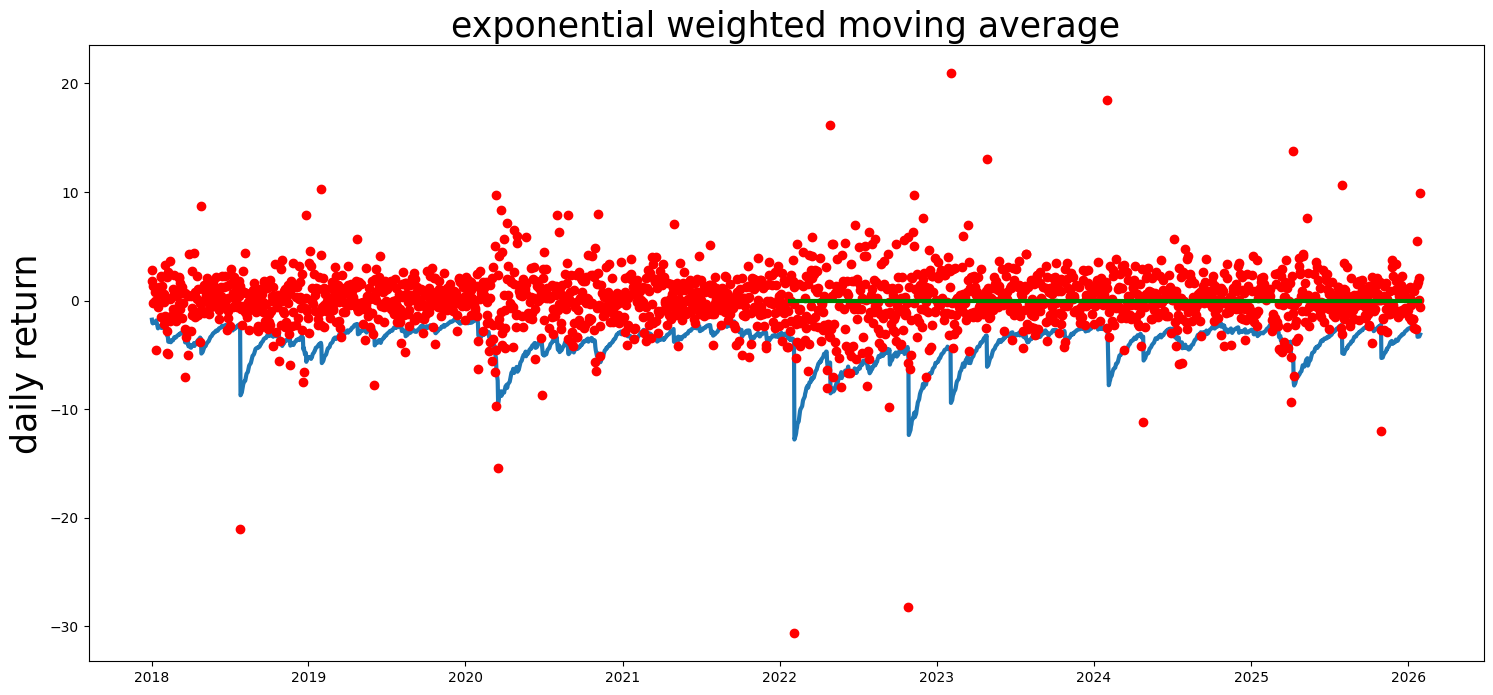

In [35]:
train2 = train * train

wt = .94
vol = train2[0]
vol_history = [0,vol]  # move everything forward one day
for v in train2[1:]:
    vol = wt * vol + (1 - wt) * v
    vol_history.append(vol)
    
vol_df = pd.DataFrame(vol_history[:-1], index=train.index, columns=['vol'])
vol_df['EWMA'] = [-1.64 * math.sqrt(x) for x in vol_df['vol']]

plt.figure(figsize=(18,8))
plt.plot(vol_df['2018-01-01':]['EWMA'], linewidth=3)
plt.plot(pd.DataFrame(train['2018-01-01':]), 'ro')
plt.plot(pd.DataFrame([0,0],index=MAVaR60_df[start_date:].index[[0,-1]]), 'g-',linewidth=3)
plt.title('exponential weighted moving average', fontsize=25)
plt.ylabel('daily return', fontsize=25)
plt.show()

# GARCH(1,1) model

$$\sigma^2_n = \omega + \alpha u^2_{n-1} + \beta \sigma^2_{n-1}$$

Iteration:      1,   Func. Count:      5,   Neg. LLF: 8581809.038034065
Iteration:      2,   Func. Count:     12,   Neg. LLF: 1518.8039854334183
Iteration:      3,   Func. Count:     17,   Neg. LLF: 1517.32372888417
Iteration:      4,   Func. Count:     22,   Neg. LLF: 3798.4369249743345
Iteration:      5,   Func. Count:     31,   Neg. LLF: 1605.2403391510202
Iteration:      6,   Func. Count:     36,   Neg. LLF: 1501.6570219515713
Iteration:      7,   Func. Count:     41,   Neg. LLF: 1520.3427280951032
Iteration:      8,   Func. Count:     47,   Neg. LLF: 1496.5548680534146
Iteration:      9,   Func. Count:     52,   Neg. LLF: 1494.938661970269
Iteration:     10,   Func. Count:     57,   Neg. LLF: 1494.8026065989811
Iteration:     11,   Func. Count:     61,   Neg. LLF: 1494.791619804288
Iteration:     12,   Func. Count:     65,   Neg. LLF: 1494.791099938608
Iteration:     13,   Func. Count:     69,   Neg. LLF: 1494.7910933509997
Iteration:     14,   Func. Count:     72,   Neg. LLF: 149

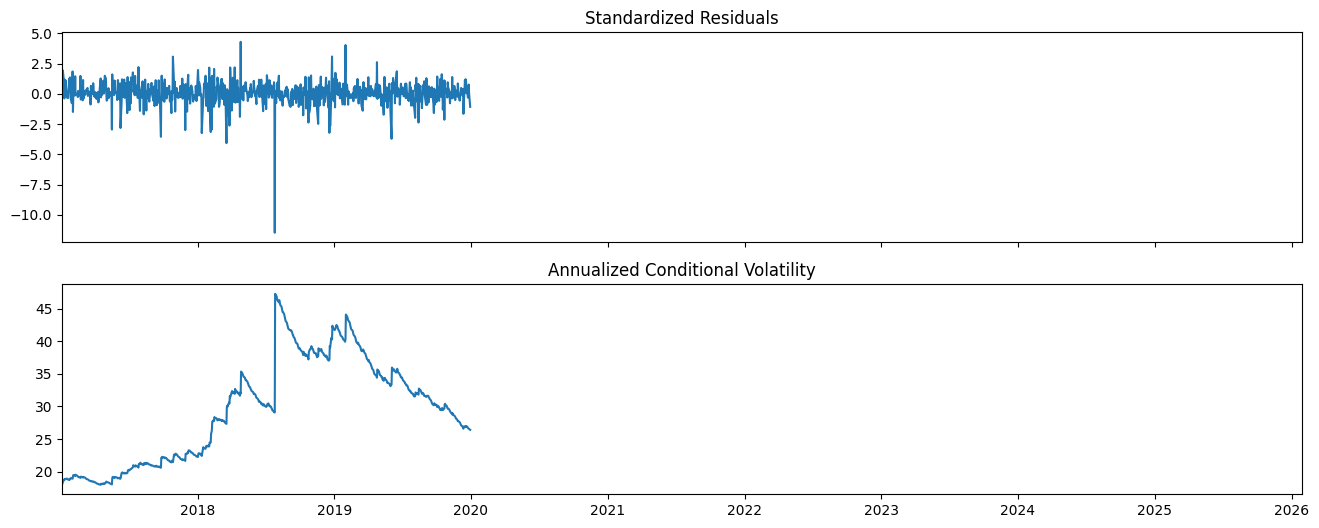

In [36]:
train = returns[ticker] * 100

model = arch_model(train, mean='Zero', vol='GARCH', p=1, q=1)
res = model.fit(last_obs='2019-12-31')
print(res.summary())
plt.rc("figure", figsize=(16, 6))
fig = res.plot(annualize='D')
print(res.params, res.tvalues, res._params, res._names)

### GARCH parameters

In [37]:
display(pd.DataFrame(res.params))
persistence = res.params['alpha[1]'] + res.params['beta[1]']
print(f"\npersistence = {persistence:0.3} (speed of mean reversion see Jorion Fig 9-6 page 229)")
print(f"unconditional variance = {res.params['omega'] / ( 1 - persistence): 0.3}")

,params
omega,0.011272
alpha[1],0.012573
beta[1],0.985784



persistence = 0.998 (speed of mean reversion see Jorion Fig 9-6 page 229)
unconditional variance =  6.86


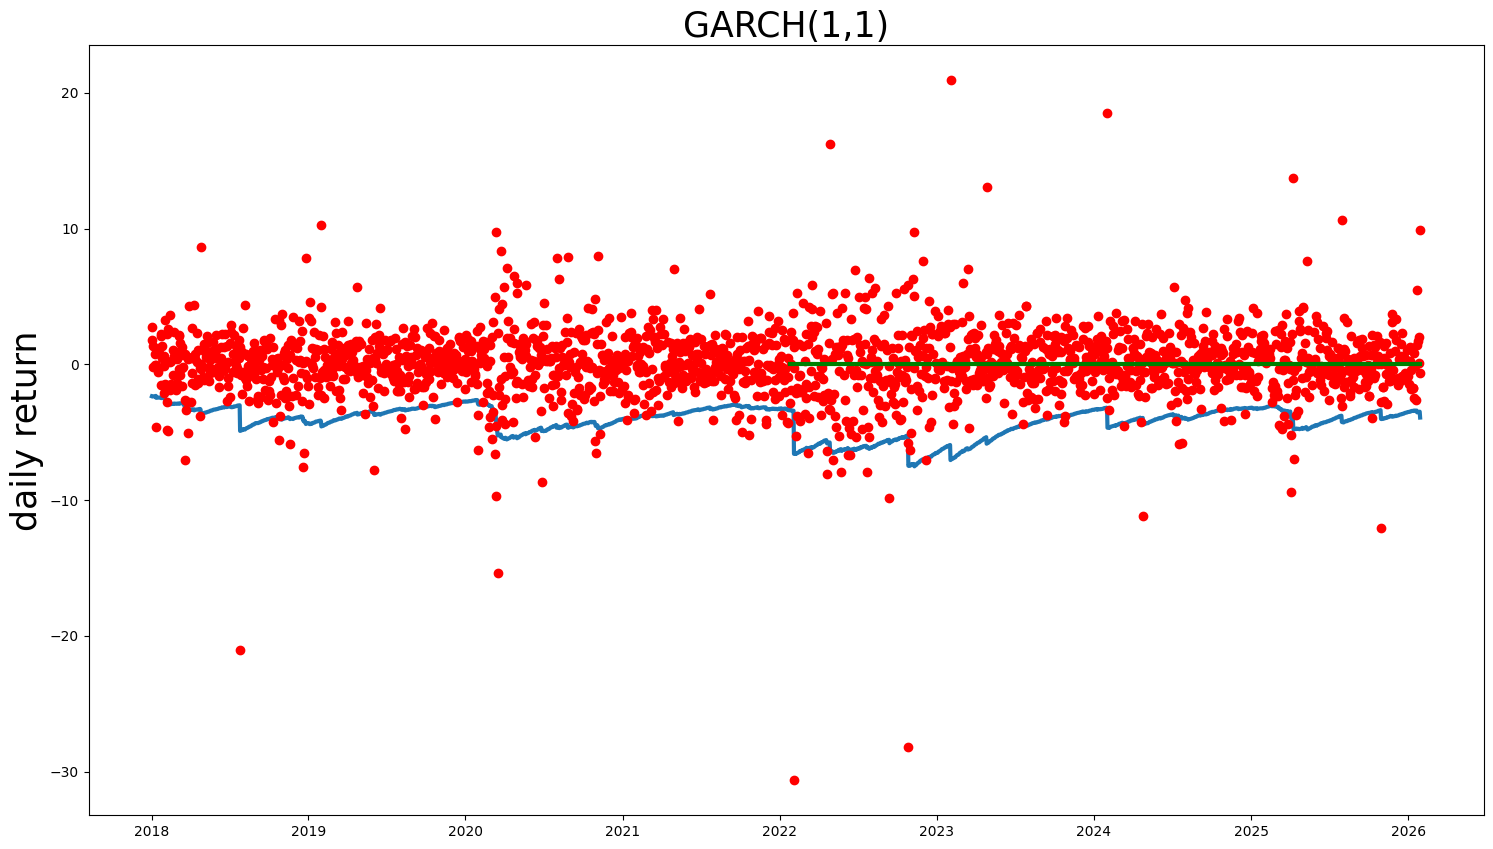

In [38]:
from arch.__future__ import reindexing

forecasts = res.forecast(start='2018-01-01') # .variance['h.1']
cond_mean = forecasts.mean['2018-01-01':]
cond_var = forecasts.variance['2018-01-01':]
q = model.distribution.ppf([p]) 
value_at_risk = pd.DataFrame([-x[0] for x in -cond_mean.values - np.sqrt(cond_var).values * q], 
                             index=train['2018-01-01':].index)
plt.figure(figsize=(18,10))
plt.plot(value_at_risk, linewidth=3)
plt.plot(train['2018-01-01':], 'ro')
plt.plot(pd.DataFrame([0,0],index=MAVaR60_df[start_date:].index[[0,-1]]), 'g-',linewidth=3)
plt.title('GARCH(1,1)', fontsize=25)
plt.ylabel('daily return', fontsize=25)
plt.show()